In [1]:
# ── UPDATE THESE THREE PATHS FOR YOUR SYSTEM ──────────────────
HDR_PATH   = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\f250812t01p00r14rfl\f250812t01p00r14_rfl.hdr"
IMG_PATH   = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\f250812t01p00r14rfl\f250812t01p00r14_rfl"
OUTPUT_DIR = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\aviris_refl_outputs"
# ─────────────────────────────────────────────────────────────

ROW_START    = 0
ROW_END      = None        
PATCH_SIZE   = 7
SAMPLE_LIMIT = 1_000_000
TEST_SPLIT   = 0.2
RANDOM_SEED  = 42
N_CLUSTERS   = 12

In [2]:
import sys
!{sys.executable} -m pip install spectral tensorly psutil scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import tensorly as tl
import psutil
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split

HDR_PATH   = HDR_PATH.strip()
IMG_PATH   = IMG_PATH.strip()
OUTPUT_DIR = OUTPUT_DIR.strip()
os.makedirs(OUTPUT_DIR, exist_ok=True)

ram = psutil.virtual_memory()
print(f"System RAM  : {ram.total/1e9:.1f} GB total  |  {ram.available/1e9:.1f} GB available")
print(f"Estimated patch size for {SAMPLE_LIMIT:,} pixels : "
      f"{SAMPLE_LIMIT * PATCH_SIZE * PATCH_SIZE * 175 * 4 / 1e9:.2f} GB")

for label, path in [("HDR", HDR_PATH), ("IMG", IMG_PATH)]:
    if os.path.exists(path):
        print(f"  [{label}] FOUND  ({os.path.getsize(path)/1e6:.1f} MB)")
    else:
        raise FileNotFoundError(f"{label} not found: {path}")


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


System RAM  : 137.1 GB total  |  120.1 GB available
Estimated patch size for 1,000,000 pixels : 34.30 GB
  [HDR] FOUND  (0.0 MB)
  [IMG] FOUND  (21122.2 MB)


In [3]:
print("STEP 1 — Loading DS")
img         = envi.open(HDR_PATH, IMG_PATH)
wavelengths = np.array(img.bands.centers)

print(f"  Full image size  : {img.shape}  (rows, cols, bands)")

if ROW_END is None:
    ROW_END = img.shape[0]

# ── memmap read — much faster than read_subimage ──────────
mmap   = img.open_memmap(writeable=False)
subset = np.array(mmap[ROW_START:ROW_END, :, :], dtype=np.float32)
del mmap
# ──────────────────────────────────────────────────────────

subset = np.where(subset < -0.5, 0.0, subset)   # kill fill values (-0.9999)
subset = np.clip(subset, 0.0, 1.0)               # clip stray spikes to [0,1]

print(f"  Loaded subset    : {subset.shape}")
print(f"  Wavelength range : {wavelengths[0]:.1f} - {wavelengths[-1]:.1f} nm")
print(f"  Value range      : [{subset.min():.4f}, {subset.max():.4f}]")
print(f"  Memory used      : {subset.nbytes / 1e9:.2f} GB")

STEP 1 — Loading DS
  Full image size  : (11274, 2091, 224)  (rows, cols, bands)
  Loaded subset    : (11274, 2091, 224)
  Wavelength range : 378.9 - 2498.3 nm
  Value range      : [0.0000, 1.0000]
  Memory used      : 21.12 GB



-------------------------------------------------------
STEP 2 — Visualize
-------------------------------------------------------


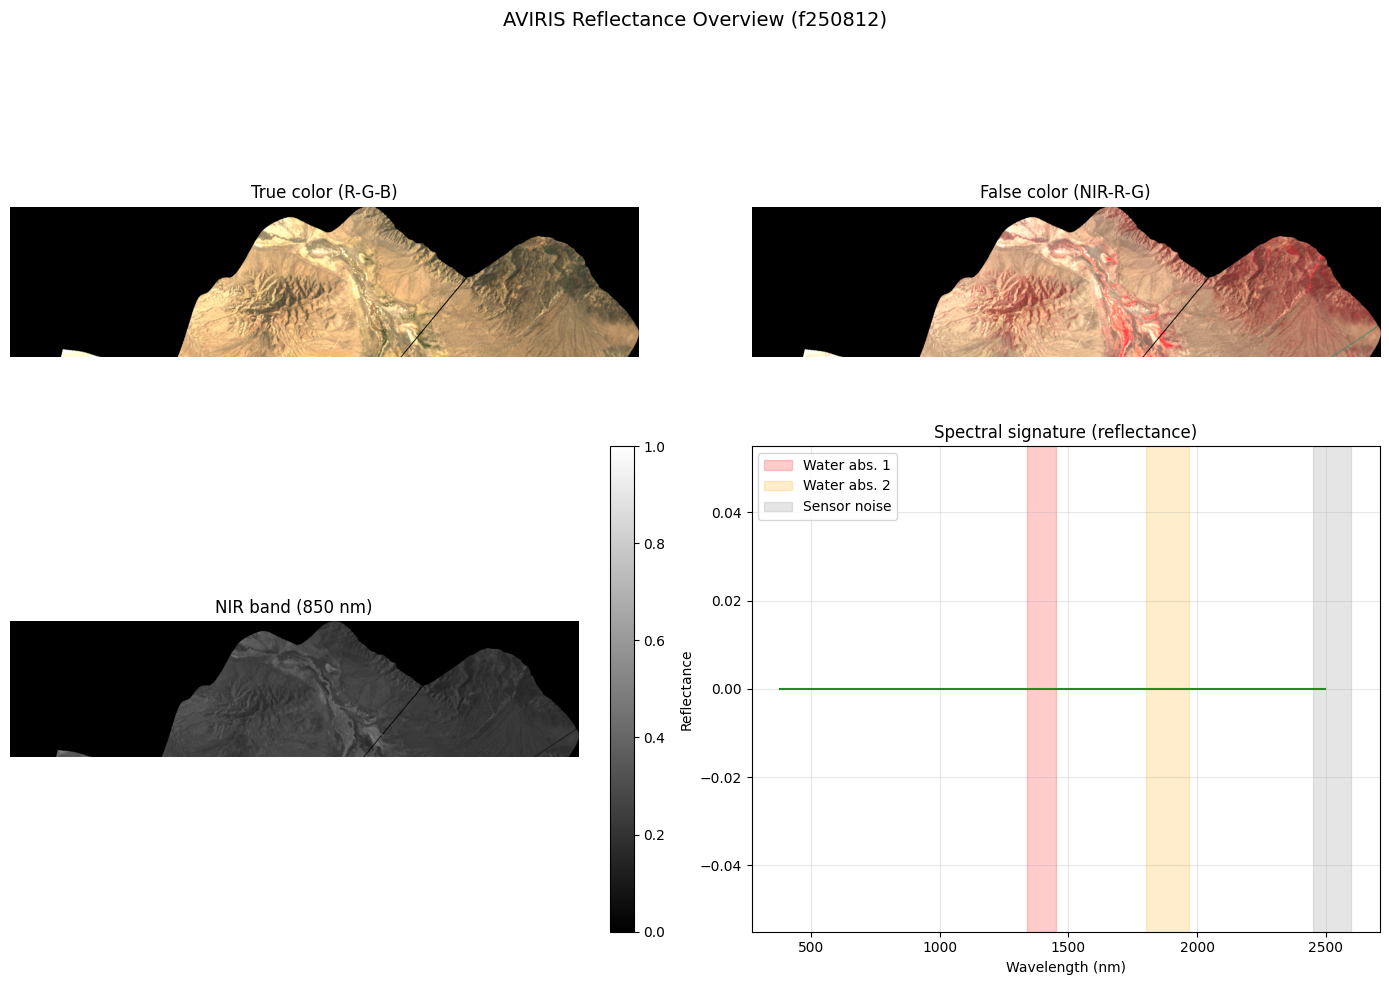

In [4]:
print("\n" + "-"*55)
print("STEP 2 — Visualize")
print("-"*55)

def find_band(wl, nm):
    return int(np.argmin(np.abs(wl - nm)))

def pct_stretch(arr, lo=2, hi=98):
    lo_v, hi_v = np.percentile(arr, [lo, hi])
    return np.clip((arr - lo_v) / (hi_v - lo_v + 1e-8), 0, 1)

vis = subset[:min(500, subset.shape[0])]
b_nir, b_red = find_band(wavelengths, 850), find_band(wavelengths, 660)
b_grn, b_blu = find_band(wavelengths, 550), find_band(wavelengths, 460)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(pct_stretch(vis[:, :, [b_red, b_grn, b_blu]]))
axes[0, 0].set_title("True color (R-G-B)"); axes[0, 0].axis("off")
axes[0, 1].imshow(pct_stretch(vis[:, :, [b_nir, b_red, b_grn]]))
axes[0, 1].set_title("False color (NIR-R-G)"); axes[0, 1].axis("off")
im = axes[1, 0].imshow(vis[:, :, b_nir], cmap="gray")
plt.colorbar(im, ax=axes[1, 0], fraction=0.046)
axes[1, 0].set_title("NIR band (850 nm)"); axes[1, 0].axis("off")
px = subset[min(250, subset.shape[0]-1), 400, :]
axes[1, 1].plot(wavelengths, px, color="forestgreen", lw=1.5)
axes[1, 1].axvspan(1340, 1450, alpha=0.2, color="red",    label="Water abs. 1")
axes[1, 1].axvspan(1800, 1970, alpha=0.2, color="orange", label="Water abs. 2")
axes[1, 1].axvspan(2450, 2600, alpha=0.2, color="gray",   label="Sensor noise")
axes[1, 1].set_xlabel("Wavelength (nm)"); axes[1, 1].set_ylabel("Reflectance")
axes[1, 1].set_title("Spectral signature (reflectance)"); axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.suptitle("AVIRIS Reflectance Overview (f250812)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

In [5]:
print("\n" + "-"*55)
print("STEP 3 — Bad band removal")
print("-"*55)

good_mask = (
    ((wavelengths >= 400)  & (wavelengths < 1340)) |
    ((wavelengths > 1450)  & (wavelengths < 1800)) |
    ((wavelengths > 2000)  & (wavelengths <= 2450))

)
good_idx        = np.where(good_mask)[0]
wavelengths_ok  = wavelengths[good_idx]

# This is already reflectance — no DOS needed later
refl_184        = subset[:, :, good_idx].copy()
wavelengths_184 = wavelengths[good_idx]

data = refl_184.copy()
del subset

print(f"  Bands kept      : {good_idx.size} / {len(wavelengths)}")
print(f"  Data shape      : {data.shape}")
print(f"  Value range     : [{data.min():.4f}, {data.max():.4f}]  ← already reflectance")


-------------------------------------------------------
STEP 3 — Bad band removal
-------------------------------------------------------
  Bands kept      : 182 / 224
  Data shape      : (11274, 2091, 182)
  Value range     : [0.0000, 1.0000]  ← already reflectance


In [6]:
print("\n" + "-"*55)
print("STEP 4 — Clip & fix values")
print("-"*55)

# Clip to valid reflectance range [0, 1]
data = np.clip(data, 0, 1)
data = np.nan_to_num(data, nan=0.0, posinf=1.0, neginf=0.0)

print(f"  Range : [{data.min():.4f}, {data.max():.4f}]  ← clipped to [0, 1]")
print(f"  NaN   : {np.isnan(data).any()}   Inf : {np.isinf(data).any()}")


-------------------------------------------------------
STEP 4 — Clip & fix values
-------------------------------------------------------
  Range : [0.0000, 1.0000]  ← clipped to [0, 1]
  NaN   : False   Inf : False



-------------------------------------------------------
STEP 5 — Variance-based band filtering
-------------------------------------------------------
  Bands after filter : 172  (removed 10)


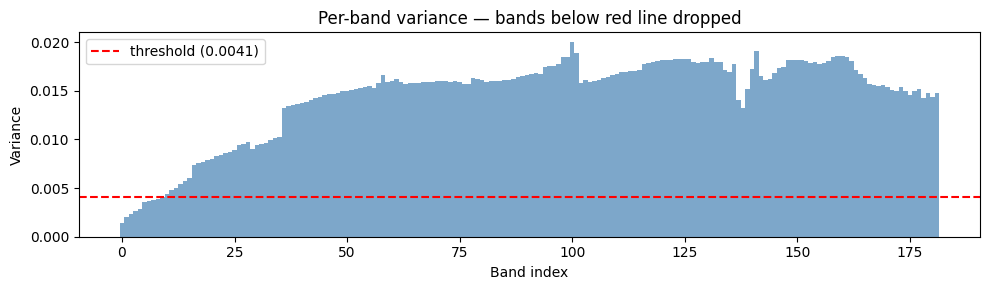

  Saved -> 02_band_variance.png


In [7]:
print("\n" + "-"*55)
print("STEP 5 — Variance-based band filtering")
print("-"*55)

rows, cols, n_bands = data.shape
band_var   = data.reshape(-1, n_bands).var(axis=0)
threshold  = np.percentile(band_var, 5)
keep_mask  = band_var > threshold

# Save reflectance data BEFORE filtering for clustering
# (clustering uses refl_184 which has all 184 bands — we keep it separate)
data           = data[:, :, keep_mask]
wavelengths_ok = wavelengths_ok[keep_mask]

# Also filter refl_184 to same bands for clustering consistency
refl_184_filt        = refl_184[:, :, keep_mask]
wavelengths_184_filt = wavelengths_184[keep_mask]

print(f"  Bands after filter : {data.shape[2]}  (removed {keep_mask.size - keep_mask.sum()})")

plt.figure(figsize=(10, 3))
plt.bar(range(n_bands), band_var, width=1, color="steelblue", alpha=0.7)
plt.axhline(threshold, color="red", linestyle="--", label=f"threshold ({threshold:.4f})")
plt.xlabel("Band index"); plt.ylabel("Variance")
plt.title("Per-band variance — bands below red line dropped")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_band_variance.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> 02_band_variance.png")

In [8]:
print("\n" + "-"*55)
print("STEP 6 — Per-band Z-score normalization")
print("-"*55)

rows, cols, nb = data.shape
X_flat    = data.reshape(-1, nb).astype(np.float32)

band_mean = X_flat.mean(axis=0)
band_std  = X_flat.std(axis=0)
band_std  = np.where(band_std < 1e-8, 1e-8, band_std)

X_norm    = (X_flat - band_mean) / band_std
data_norm = X_norm.reshape(rows, cols, nb)

# Clip Z-score outliers (beyond ±5 std is noise)
data_norm = np.clip(data_norm, -5.0, 5.0)
print(f"  After outlier clip : [{data_norm.min():.3f}, {data_norm.max():.3f}]")

del X_flat, X_norm, data

print(f"  Shape  : {data_norm.shape}")
print(f"  Mean   : {data_norm.mean():.6f}  (should be ~0)")
print(f"  Std    : {data_norm.std():.6f}   (should be ~1)")
print(f"  Memory : {data_norm.nbytes / 1e9:.2f} GB")

np.savez(
    os.path.join(OUTPUT_DIR, "band_metadata.npz"),
    wavelengths = wavelengths_ok,
    band_mean   = band_mean,
    band_std    = band_std
)
print("  Saved band_metadata.npz ✓")

# NOTE: Step 7 (DOS correction) is REMOVED.
# f250812 is already atmospherically corrected surface reflectance
# from JPL — no conversion needed.
print("\n  ✓ Skipping DOS — data is already surface reflectance")


-------------------------------------------------------
STEP 6 — Per-band Z-score normalization
-------------------------------------------------------
  After outlier clip : [-0.791, 5.000]
  Shape  : (11274, 2091, 172)
  Mean   : -0.000044  (should be ~0)
  Std    : 0.999734   (should be ~1)
  Memory : 16.22 GB
  Saved band_metadata.npz ✓

  ✓ Skipping DOS — data is already surface reflectance


In [9]:
print("\n" + "-"*55)
print("STEP 7 — ISODATA parameter search (find optimal N_CLUSTERS)")
print("-"*55)

# ISODATA is not in scikit-learn — pure NumPy implementation
# Key difference from K-Means:
#   - Automatically SPLITS clusters that are too spread out
#   - Automatically MERGES clusters that are too close together
#   - Final number of clusters is determined by the data, not fixed

import numpy as np

def isodata(data, n_init=8, max_iter=50,
            min_samples=10, max_std=0.3,
            min_distance=0.1, max_merge=2,
            random_seed=42):
    """
    ISODATA clustering — standard remote sensing unsupervised classifier.

    Parameters
    ----------
    data        : (n_pixels, n_bands) float32
    n_init      : initial number of clusters
    max_iter    : maximum iterations
    min_samples : minimum pixels per cluster (below → cluster deleted)
    max_std     : max std dev per cluster (above → cluster split)
    min_distance: min distance between centres (below → clusters merged)
    max_merge   : max pairs to merge per iteration

    Returns
    -------
    labels   : (n_pixels,) int32  — cluster id 0..K-1
    centres  : (K, n_bands) float32
    """
    rng  = np.random.default_rng(random_seed)
    n, d = data.shape

    # Initialise centres randomly from data
    idx     = rng.choice(n, size=n_init, replace=False)
    centres = data[idx].copy().astype(np.float64)

    labels  = np.zeros(n, dtype=np.int32)

    for it in range(max_iter):
        # ── Assignment ───────────────────────────────────────
        # Compute distances in chunks to avoid RAM spike
        CHUNK = 50_000
        new_labels = np.zeros(n, dtype=np.int32)
        for start in range(0, n, CHUNK):
            end   = min(start + CHUNK, n)
            chunk = data[start:end].astype(np.float64)
            # (chunk, 1, d) - (1, K, d) → (chunk, K)
            dists = np.linalg.norm(
                chunk[:, None, :] - centres[None, :, :], axis=2
            )
            new_labels[start:end] = np.argmin(dists, axis=1)

        changed = (new_labels != labels).sum()
        labels  = new_labels

        # ── Update centres ───────────────────────────────────
        new_centres = []
        for k in range(len(centres)):
            mask = labels == k
            if mask.sum() >= min_samples:
                new_centres.append(data[mask].mean(axis=0).astype(np.float64))
        
        if len(new_centres) == 0:
            break
        centres = np.array(new_centres)
        K       = len(centres)

        # Reassign labels after deletion
        for k in range(K):
            mask = labels == [i for i in range(K+K)][k]

        # ── Split clusters with high std ─────────────────────
        split_centres = []
        for k in range(K):
            mask = labels == k
            if mask.sum() < min_samples * 2:
                split_centres.append(centres[k])
                continue
            std = data[mask].std(axis=0).mean()
            if std > max_std:
                # Split along highest variance dimension
                hi_var = data[mask].var(axis=0).argmax()
                delta  = np.zeros(centres[k].shape)
                delta[hi_var] = std * 0.5
                split_centres.append(centres[k] + delta)
                split_centres.append(centres[k] - delta)
            else:
                split_centres.append(centres[k])
        centres = np.array(split_centres)
        K       = len(centres)

        # ── Merge close clusters ──────────────────────────────
        merged = set()
        merge_pairs = []
        for i in range(K):
            for j in range(i+1, K):
                d = np.linalg.norm(centres[i] - centres[j])
                if d < min_distance:
                    merge_pairs.append((d, i, j))
        merge_pairs.sort()

        new_centres = list(centres)
        for _, i, j in merge_pairs[:max_merge]:
            if i in merged or j in merged:
                continue
            # Merge i and j → weighted mean
            ni = (labels == i).sum()
            nj = (labels == j).sum()
            if ni + nj == 0: continue
            merged_c = (centres[i]*ni + centres[j]*nj) / (ni+nj)
            new_centres[i] = merged_c
            new_centres[j] = None
            merged.add(j)

        centres = np.array([c for c in new_centres if c is not None])
        K       = len(centres)

        print(f"    Iter {it+1:3d} | K={K:3d} | changed={changed:,}", end="\r")
        if changed == 0:
            break

    print(f"    Converged at iter {it+1} | Final K={K}          ")

    # Final assignment
    CHUNK = 50_000
    final_labels = np.zeros(n, dtype=np.int32)
    for start in range(0, n, CHUNK):
        end   = min(start + CHUNK, n)
        chunk = data[start:end].astype(np.float64)
        dists = np.linalg.norm(
            chunk[:, None, :] - centres[None, :, :], axis=2
        )
        final_labels[start:end] = np.argmin(dists, axis=1)

    return final_labels.astype(np.int32), centres.astype(np.float32)


# ── Run parameter search to find good N_CLUSTERS ─────────────
flat_refl  = refl_184_filt.reshape(-1, refl_184_filt.shape[2]).astype(np.float32)
valid_mask = flat_refl.max(axis=1) > 0.01
valid_idx  = np.where(valid_mask)[0]

# Use 100k sample for parameter search — ISODATA is slower than K-Means
sample_idx = np.random.default_rng(RANDOM_SEED).choice(
    valid_idx, size=min(100_000, len(valid_idx)), replace=False
)
sample = flat_refl[sample_idx]
print(f"  ISODATA parameter search sample : {len(sample_idx):,} pixels")
print(f"  Running ISODATA with n_init=8 ...")

_, centres_search = isodata(
    sample, n_init=8, max_iter=30,
    min_samples=50, max_std=0.25,
    min_distance=0.08, random_seed=RANDOM_SEED
)
print(f"  ISODATA found {len(centres_search)} natural clusters")
print(f"  → Update N_CLUSTERS in Cell 0 to {len(centres_search)}")

# Update N_CLUSTERS automatically
N_CLUSTERS = len(centres_search)
print(f"  N_CLUSTERS set to {N_CLUSTERS}")



-------------------------------------------------------
STEP 7 — ISODATA parameter search (find optimal N_CLUSTERS)
-------------------------------------------------------
  ISODATA parameter search sample : 100,000 pixels
  Running ISODATA with n_init=8 ...
    Converged at iter 30 | Final K=8          
  ISODATA found 8 natural clusters
  → Update N_CLUSTERS in Cell 0 to 8
  N_CLUSTERS set to 8



-------------------------------------------------------
STEP 8 — ISODATA clustering on reflectance
-------------------------------------------------------
  Total pixels  : 23,573,934
  Valid pixels  : 9,359,791
  Running ISODATA on ALL valid pixels ...
  Memory for fit data : 6.44 GB
  (This may take 10-20 minutes for full dataset)
    Converged at iter 50 | Final K=8          
  ISODATA final clusters : 8

  Pixels per cluster:
    [0]  2,054,482  ██████████████████████████████████
    [1]  2,623,204  ████████████████████████████████████████
    [2]  1,740,919  █████████████████████████████
    [3]  1,172,417  ███████████████████
    [4]   329,791  █████
    [5]   187,865  ███
    [6]   796,287  █████████████
    [7]   454,826  ███████


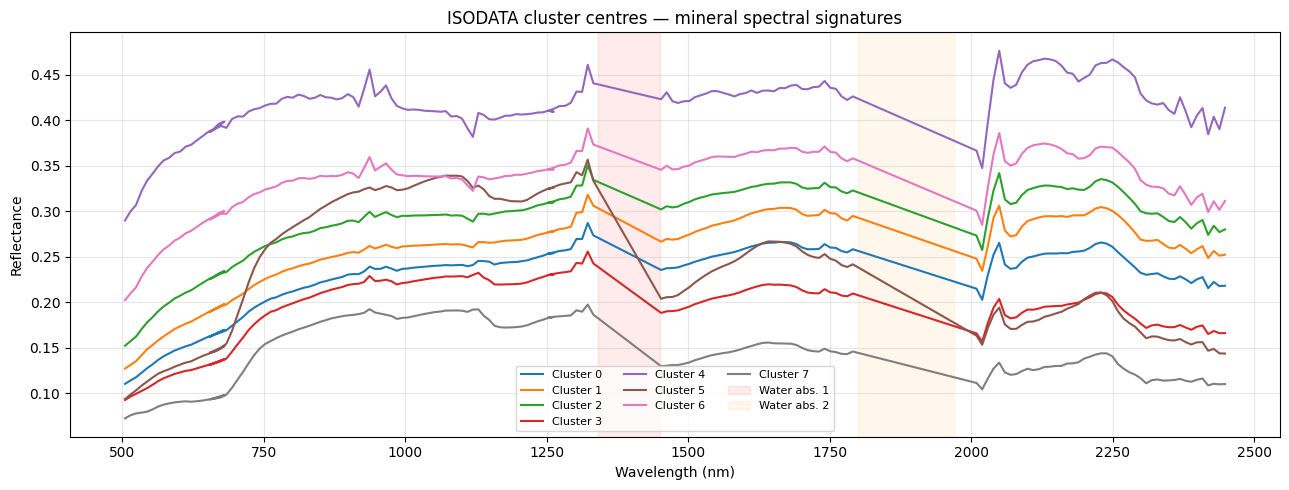

  Saved → 03_cluster_spectra.png


In [10]:
print("\n" + "-"*55)
print("STEP 8 — ISODATA clustering on reflectance")
print("-"*55)

# Recompute flat_refl / valid_idx
flat_refl  = refl_184_filt.reshape(-1, refl_184_filt.shape[2]).astype(np.float32)
valid_mask = flat_refl.max(axis=1) > 0.01
valid_idx  = np.where(valid_mask)[0]

print(f"  Total pixels  : {len(flat_refl):,}")
print(f"  Valid pixels  : {len(valid_idx):,}")
print(f"  Running ISODATA on ALL valid pixels ...")
print(f"  Memory for fit data : {flat_refl[valid_idx].nbytes / 1e9:.2f} GB")
print(f"  (This may take 10-20 minutes for full dataset)")

fit_data = flat_refl[valid_idx]

isodata_labels, isodata_centres = isodata(
    fit_data,
    n_init       = N_CLUSTERS,   # start with N_CLUSTERS from search
    max_iter     = 50,
    min_samples  = 1000,         # min pixels per cluster
    max_std      = 0.25,         # split if std > this
    min_distance = 0.08,         # merge if distance < this
    max_merge    = 2,
    random_seed  = RANDOM_SEED
)

# Update N_CLUSTERS to final value after splits/merges
N_CLUSTERS = len(isodata_centres)
print(f"  ISODATA final clusters : {N_CLUSTERS}")

# Build class map
labels_flat            = np.zeros(rows * cols, dtype=np.int32)
labels_flat[valid_idx] = isodata_labels + 1   # 1-indexed, 0=skipped
class_map              = labels_flat.reshape(rows, cols)

print(f"\n  Pixels per cluster:")
for i in range(N_CLUSTERS):
    count = (class_map == i+1).sum()
    bar   = "█" * min(40, count // max(1, class_map.size // 400))
    print(f"    [{i}]  {count:>8,}  {bar}")

# Plot cluster centre spectra
colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(13, 5))
for i in range(N_CLUSTERS):
    ax.plot(wavelengths_184_filt, isodata_centres[i],
            color=colors[i%10], lw=1.5, label=f"Cluster {i}")
ax.axvspan(1340, 1450, alpha=0.08, color="red",    label="Water abs. 1")
ax.axvspan(1800, 1970, alpha=0.08, color="orange", label="Water abs. 2")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Reflectance")
ax.set_title("ISODATA cluster centres — mineral spectral signatures")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_cluster_spectra.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → 03_cluster_spectra.png")



-------------------------------------------------------
STEP 9 — Pixel selection from ISODATA
-------------------------------------------------------


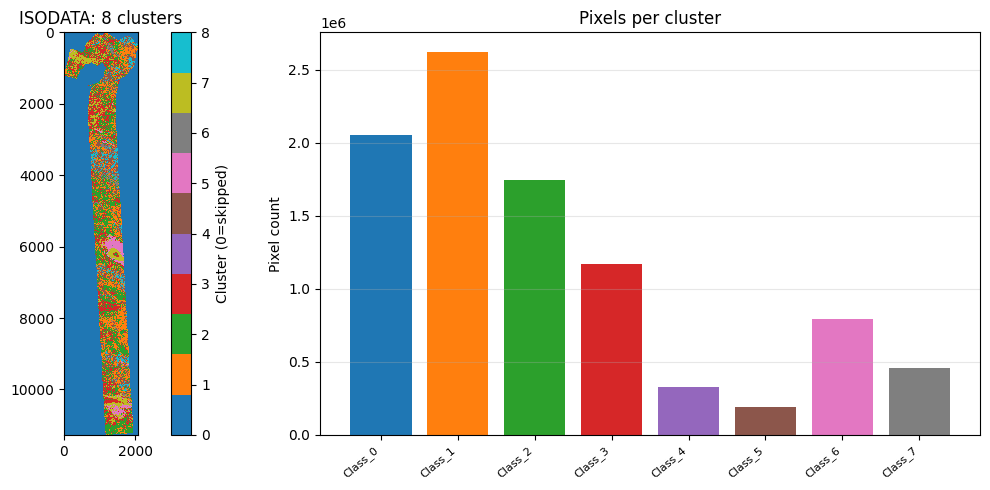

  pixel_idx  : 999,996 pixels
  labels_sel : (999996,)  classes: [0 1 2 3 4 5 6 7]
  Saved class_info.npz ✓

  NOTE: Class names are Class_0 to Class_N for now.
  Run Step 9b (SAM matching) to replace with USGS mineral names.



In [12]:
print("\n" + "-"*55)
print("STEP 9 — Pixel selection from ISODATA")
print("-"*55)

CLASS_NAMES = [f"Class_{i}" for i in range(N_CLUSTERS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(class_map, cmap="tab10",
                    vmin=0, vmax=N_CLUSTERS, interpolation="none")
plt.colorbar(im, ax=axes[0], label="Cluster (0=skipped)")
axes[0].set_title(f"ISODATA: {N_CLUSTERS} clusters")
counts = [int((class_map == i+1).sum()) for i in range(N_CLUSTERS)]
colors = plt.cm.tab10.colors
axes[1].bar(range(N_CLUSTERS), counts, color=list(colors[:N_CLUSTERS]))
axes[1].set_xticks(range(N_CLUSTERS))
axes[1].set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=8)
axes[1].set_ylabel("Pixel count")
axes[1].set_title("Pixels per cluster")  # ← changed
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_classification_map.png"), dpi=150, bbox_inches="tight")
plt.show()

lf           = class_map.flatten()
labelled_idx = np.where(lf > 0)[0]
labels_all   = lf[labelled_idx] - 1   # 0-indexed

rng = np.random.default_rng(RANDOM_SEED)
if len(labelled_idx) > SAMPLE_LIMIT:
    chosen = []
    for cls in range(N_CLUSTERS):
        cls_idx = np.where(labels_all == cls)[0]
        n_take  = max(1, int(SAMPLE_LIMIT * len(cls_idx) / len(labelled_idx)))
        if len(cls_idx) > 0:
            sel = rng.choice(cls_idx, size=min(n_take, len(cls_idx)), replace=False)
            chosen.extend(sel.tolist())
    chosen     = np.array(sorted(chosen))
    pixel_idx  = labelled_idx[chosen]
    labels_sel = labels_all[chosen]
else:
    pixel_idx  = labelled_idx
    labels_sel = labels_all

print(f"  pixel_idx  : {len(pixel_idx):,} pixels")
print(f"  labels_sel : {labels_sel.shape}  classes: {np.unique(labels_sel)}")

np.savez(os.path.join(OUTPUT_DIR, "class_info.npz"),
         class_names=np.array(CLASS_NAMES, dtype=object),
         n_classes=N_CLUSTERS, method="isodata")  # ← changed
print("  Saved class_info.npz ✓")
print("""
  NOTE: Class names are Class_0 to Class_N for now.
  Run Step 9b (SAM matching) to replace with USGS mineral names.
""")

In [13]:
# STEP 9b — USGS splib07 SAM matching
print("\n" + "-"*55)
print("STEP 9b — USGS splib07 SAM matching")
print("-"*55)

import os
import numpy as np

LIBRARY_DIR = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\usgs_splib07\ASCIIdata\ASCIIdata_splib07b_cvAVIRISc2014"
CHAPTERS    = ["ChapterM_Minerals", "ChapterS_SoilsAndMixtures"]

# ── Step 1: Load sensor wavelengths ──────────────────────────
wl_file = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\usgs_splib07\ASCIIdata\ASCIIdata_splib07b_cvAVIRISc2014\s07_AV14_Wavelengths_in_microns_224_ch_AVIRIS14a.txt"

sensor_wl = []
with open(wl_file, errors="ignore") as f:
    for i, line in enumerate(f):
        if i == 0: continue
        line = line.strip()
        if not line: continue
        try:
            val = float(line)
            sensor_wl.append(val * 1000)   # µm → nm
        except ValueError:
            continue
sensor_wl = np.array(sensor_wl)
print(f"  Sensor wavelengths : {len(sensor_wl)} bands")
print(f"  Range : {sensor_wl[0]:.1f} – {sensor_wl[-1]:.1f} nm")

# ── Step 2: Load spectra ──────────────────────────────────────
def load_chapter(chapter_dir, sensor_wl, target_wl):
    names, spectra = [], []
    txt_files = sorted([f for f in os.listdir(chapter_dir)
                        if f.endswith(".txt")])
    for fname in txt_files:
        refl = []
        with open(os.path.join(chapter_dir, fname), errors="ignore") as f:
            for i, line in enumerate(f):
                if i == 0: continue
                line = line.strip()
                if not line: continue
                try:
                    val = float(line)
                    refl.append(val)
                except ValueError:
                    continue
        if len(refl) < 10: continue
        refl    = np.array(refl, dtype=np.float32)
        refl    = np.where(refl < -0.1, np.nan, refl)
        min_len = min(len(refl), len(sensor_wl))
        refl    = refl[:min_len]
        wl_use  = sensor_wl[:min_len]
        valid   = ~np.isnan(refl)
        if valid.sum() < 10: continue
        refl    = refl[valid]
        wl_use  = wl_use[valid]
        refl    = np.clip(refl, 0, 1)
        interp  = np.interp(target_wl, wl_use, refl, left=np.nan, right=np.nan)
        if np.isnan(interp).any(): continue
        parts    = fname.replace(".txt", "").split("_")
        mat_name = parts[2] if len(parts) > 2 else fname
        names.append(mat_name)
        spectra.append(interp.astype(np.float32))
    return names, spectra

# Load all chapters
all_names, all_spectra = [], []
for chapter in CHAPTERS:
    chapter_path = os.path.join(LIBRARY_DIR, chapter)
    n, s = load_chapter(chapter_path, sensor_wl, wavelengths_184_filt)
    all_names.extend(n)
    all_spectra.extend(s)
    print(f"  Loaded {len(n):>4} spectra from {chapter}")

if len(all_spectra) == 0:
    raise ValueError("No spectra loaded — check LIBRARY_DIR path")

lib_spectra = np.array(all_spectra, dtype=np.float32)
print(f"\n  Total library spectra : {len(all_names)}")

# ── Step 3: SAM matching ──────────────────────────────────────
# ── Step 3: SAM matching with unique assignment ───────────────
def sam_angle(a, b):
    cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

centers     = isodata_centres
CLASS_NAMES = []
used_names  = set()  # track already assigned minerals

print("\n  Cluster → Best USGS mineral match:")
print(f"  {'Cluster':<8} {'Pixels':>12}  {'Angle':>7}  Mineral")
print("  " + "-"*60)

for i, centre in enumerate(centers):
    angles = [sam_angle(centre, lib_spectra[j]) for j in range(len(lib_spectra))]
    
    # Sort by angle and pick best unused mineral
    sorted_idx = np.argsort(angles)
    for best_idx in sorted_idx:
        candidate = all_names[best_idx]
        if candidate not in used_names:
            break
    
    name  = all_names[best_idx]
    angle = angles[best_idx]
    count = int((class_map == i+1).sum())
    CLASS_NAMES.append(name)
    used_names.add(name)
    print(f"  [{i}]  {count:>12,}  {angle:>6.1f}°  {name}")

# ── Step 4: Save ──────────────────────────────────────────────
np.savez(
    os.path.join(OUTPUT_DIR, "class_info.npz"),
    class_names = np.array(CLASS_NAMES, dtype=object),
    n_classes   = N_CLUSTERS,
    method      = "kmeans+usgs_splib07_sam"
)
print(f"\n  CLASS_NAMES = {CLASS_NAMES}")
print("  Saved class_info.npz with USGS mineral names ✓")


-------------------------------------------------------
STEP 9b — USGS splib07 SAM matching
-------------------------------------------------------
  Sensor wavelengths : 224 bands
  Range : 365.9 – 2496.2 nm
  Loaded  884 spectra from ChapterM_Minerals
  Loaded  166 spectra from ChapterS_SoilsAndMixtures

  Total library spectra : 1050

  Cluster → Best USGS mineral match:
  Cluster        Pixels    Angle  Mineral
  ------------------------------------------------------------
  [0]     2,054,482     3.5°  Celestite
  [1]     2,623,204     2.8°  Sand
  [2]     1,740,919     2.8°  Andradite
  [3]     1,172,417     5.3°  Richterite
  [4]       329,791     2.4°  Microcline
  [5]       187,865     8.2°  Sepiolite
  [6]       796,287     2.6°  Mizzonite
  [7]       454,826     7.0°  Uvarovite

  CLASS_NAMES = ['Celestite', 'Sand', 'Andradite', 'Richterite', 'Microcline', 'Sepiolite', 'Mizzonite', 'Uvarovite']
  Saved class_info.npz with USGS mineral names ✓


In [14]:
print("\n" + "-"*55)
print("STEP 10 — Patch extraction")
print("-"*55)
rows, cols, nb = data_norm.shape

patch_gb = len(pixel_idx) * PATCH_SIZE * PATCH_SIZE * nb * 4 / 1e9
print(f"  Pixels to extract : {len(pixel_idx):,}")
print(f"  Patch array size  : {patch_gb:.2f} GB")

if patch_gb > psutil.virtual_memory().available / 1e9 * 0.7:
    print(f"  WARNING: May exceed available RAM. Reduce SAMPLE_LIMIT.")

print(f"\n  Padding image ...")
pad        = PATCH_SIZE // 2
padded     = np.pad(data_norm, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")
pixel_rows = pixel_idx // cols
pixel_cols = pixel_idx  % cols

print(f"  Extracting {len(pixel_idx):,} patches ({PATCH_SIZE}×{PATCH_SIZE}×{nb}) ...")
patches = np.empty((len(pixel_idx), PATCH_SIZE, PATCH_SIZE, nb), dtype=np.float32)

for i, (r, c) in enumerate(zip(pixel_rows, pixel_cols)):
    patches[i] = padded[r : r + PATCH_SIZE, c : c + PATCH_SIZE, :]
    if (i + 1) % 10_000 == 0:
        print(f"    {i+1:,} / {len(pixel_idx):,} done", end="\r")

del padded

print(f"\n  Done.")
print(f"  Patches shape  : {patches.shape}")
print(f"  Memory used    : {patches.nbytes / 1e9:.2f} GB")
print(f"  NaN?           : {np.isnan(patches).any()}")


-------------------------------------------------------
STEP 10 — Patch extraction
-------------------------------------------------------
  Pixels to extract : 999,996
  Patch array size  : 33.71 GB

  Padding image ...
  Extracting 999,996 patches (7×7×172) ...
    990,000 / 999,996 done
  Done.
  Patches shape  : (999996, 7, 7, 172)
  Memory used    : 33.71 GB
  NaN?           : False


In [16]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

print("\n" + "-"*55)
print("STEP 11 — Train/test split & save (memory safe)")
print("-"*55)

# Remove rare classes before splitting
class_counts = np.bincount(labels_sel, minlength=N_CLUSTERS)
rare_classes  = np.where(class_counts < 2)[0]
if len(rare_classes) > 0:
    print(f"  Removing {len(rare_classes)} rare class(es): {rare_classes.tolist()}")
    keep        = ~np.isin(labels_sel, rare_classes)
    patches     = patches[keep]
    labels_sel  = labels_sel[keep]
    pixel_idx   = pixel_idx[keep]
    unique_cls  = np.unique(labels_sel)
    remap       = {old: new for new, old in enumerate(unique_cls)}
    labels_sel  = np.array([remap[l] for l in labels_sel], dtype=np.int32)
    CLASS_NAMES = [CLASS_NAMES[i] for i in unique_cls]
    N_CLUSTERS  = len(unique_cls)
    print(f"  Active classes : {N_CLUSTERS}")
    
# Split indices only — no data copied
sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=RANDOM_SEED)
train_idx, test_idx = next(sss.split(np.zeros(len(labels_sel)), labels_sel))

y_train = labels_sel[train_idx]
y_test  = labels_sel[test_idx]

print(f"  Train : {len(train_idx):,} patches")
print(f"  Test  : {len(test_idx):,} patches")

# Save train patches in chunks — never allocate full copy
print("  Saving train patches ...")
train_out = np.lib.format.open_memmap(
    os.path.join(OUTPUT_DIR, "patches_train.npy"),
    mode='w+', dtype='float32',
    shape=(len(train_idx), PATCH_SIZE, PATCH_SIZE, patches.shape[3])
)
for i, idx in enumerate(train_idx):
    train_out[i] = patches[idx]
    if (i+1) % 50_000 == 0:
        print(f"    {i+1:,} / {len(train_idx):,}", end="\r")
del train_out
print(f"    Done.                    ")

# Save test patches in chunks
print("  Saving test patches ...")
test_out = np.lib.format.open_memmap(
    os.path.join(OUTPUT_DIR, "patches_test.npy"),
    mode='w+', dtype='float32',
    shape=(len(test_idx), PATCH_SIZE, PATCH_SIZE, patches.shape[3])
)
for i, idx in enumerate(test_idx):
    test_out[i] = patches[idx]
    if (i+1) % 50_000 == 0:
        print(f"    {i+1:,} / {len(test_idx):,}", end="\r")
del test_out
print(f"    Done.                    ")

# Save labels and metadata
np.save(os.path.join(OUTPUT_DIR, "labels_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "labels_test.npy"),  y_test)
np.save(os.path.join(OUTPUT_DIR, "pixel_idx.npy"),    pixel_idx)
np.save(os.path.join(OUTPUT_DIR, "isodata_centers.npy"), isodata_centres)
np.savez(
    os.path.join(OUTPUT_DIR, "class_info.npz"),
    class_names = np.array(CLASS_NAMES, dtype=object),
    n_classes   = N_CLUSTERS,
    method      = "isodata+usgs_splib07_sam"
)

print(f"\n  Saved to {OUTPUT_DIR}")
print(f"  Train class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_train == i).sum()
    print(f"    [{i}] {name:<30}  {count:>6,}")

# Load back as memmaps for Step 12 (no RAM cost)
X_train = np.load(os.path.join(OUTPUT_DIR, "patches_train.npy"), mmap_mode='r')
X_test  = np.load(os.path.join(OUTPUT_DIR, "patches_test.npy"),  mmap_mode='r')
print(f"\n  X_train : {X_train.shape}  X_test : {X_test.shape}")


-------------------------------------------------------
STEP 11 — Train/test split & save (memory safe)
-------------------------------------------------------
  Train : 799,996 patches
  Test  : 200,000 patches
  Saving train patches ...
    Done.                    
  Saving test patches ...
    Done.                    

  Saved to C:\Users\PESU-RF\Desktop\Capstone Team - 88\aviris_refl_outputs
  Train class distribution:
    [0] Celestite                       175,600
    [1] Sand                            224,210
    [2] Andradite                       148,799
    [3] Richterite                      100,209
    [4] Microcline                      28,187
    [5] Sepiolite                       16,057
    [6] Mizzonite                       68,060
    [7] Uvarovite                       38,874

  X_train : (799996, 7, 7, 172)  X_test : (200000, 7, 7, 172)


In [17]:
# STEP 12 — Tensor formatting for TTN
print("\n" + "-"*55)
print("STEP 12 — Tensor formatting for TTN")
print("-"*55)

N_tr, P, _, B = X_train.shape
N_te          = X_test.shape[0]

# TensorLy works directly with numpy float32 arrays
X_train_4d = X_train   # (N, 7, 7, nb) — ready for TTN
X_test_4d  = X_test

print(f"  Train tensor : {X_train_4d.shape}  dtype: {X_train_4d.dtype}")
print(f"  Test  tensor : {X_test_4d.shape}   dtype: {X_test_4d.dtype}")
print(f"  Train labels : {y_train.shape}  classes: {np.unique(y_train)}")
print(f"  Test  labels : {y_test.shape}")
print(f"\n  Memory used  : {X_train_4d.nbytes / 1e9:.1f} GB")
print("\n  → X_train_4d and y_train ready for TTN model.")


-------------------------------------------------------
STEP 12 — Tensor formatting for TTN
-------------------------------------------------------
  Train tensor : (799996, 7, 7, 172)  dtype: float32
  Test  tensor : (200000, 7, 7, 172)   dtype: float32
  Train labels : (799996,)  classes: [0 1 2 3 4 5 6 7]
  Test  labels : (200000,)

  Memory used  : 27.0 GB

  → X_train_4d and y_train ready for TTN model.


In [18]:
# PREPROCESSING COMPLETE
print("\n" + "="*55)
print("        PREPROCESSING COMPLETE")
print("="*55)
print(f"  Source file              : f250812t01p00r14_rfl  (reflectance)")
print(f"  Rows loaded              : {ROW_END - ROW_START}")
print(f"  After bad band removal   : {good_idx.size} bands")
print(f"  After variance filter    : {nb} bands")
print(f"  Pixels extracted         : {len(pixel_idx):,}")
print(f"  Patches shape            : {patches.shape}")
print(f"  Active classes           : {N_CLUSTERS}")
print(f"  Class names              : {CLASS_NAMES}")
print(f"  Train tensor (Format A)  : {X_train_4d.shape}")
print(f"  Test  tensor (Format A)  : {X_test_4d.shape}")

chunk_size = 100_000
has_nan    = False
for start in range(0, len(patches), chunk_size):
    if np.isnan(patches[start:start+chunk_size]).any():
        has_nan = True
        break
print(f"  NaN in patches?          : {has_nan}")

p_min, p_max = np.inf, -np.inf
for start in range(0, len(patches), chunk_size):
    chunk = patches[start:start+chunk_size]
    p_min = min(p_min, float(chunk.min()))
    p_max = max(p_max, float(chunk.max()))
print(f"  Value range              : [{p_min:.3f}, {p_max:.3f}]")
print("="*55)
print(f"  Outputs → {OUTPUT_DIR}")
print("="*55)
print("""
  KEY CHANGES vs RADIANCE VERSION:
  ─────────────────────────────────────────────────────
  Paths    : f250812 reflectance file (JPL corrected)
  Step 1   : Auto scale-factor detection (÷10000)
  Step 4   : Clip to [0,1] (reflectance range)
  Step 5   : refl_184_filt saved for clustering
  Step 7   : DOS correction REMOVED (not needed)
  Step 8   : KMeans on true reflectance (cleaner)
  Step 9b  : SAM uses wavelengths_184_filt
  ─────────────────────────────────────────────────────
  X_train_4d + y_train → ready for TTN model
""")


        PREPROCESSING COMPLETE
  Source file              : f250812t01p00r14_rfl  (reflectance)
  Rows loaded              : 11274
  After bad band removal   : 182 bands
  After variance filter    : 172 bands
  Pixels extracted         : 999,996
  Patches shape            : (999996, 7, 7, 172)
  Active classes           : 8
  Class names              : ['Celestite', 'Sand', 'Andradite', 'Richterite', 'Microcline', 'Sepiolite', 'Mizzonite', 'Uvarovite']
  Train tensor (Format A)  : (799996, 7, 7, 172)
  Test  tensor (Format A)  : (200000, 7, 7, 172)
  NaN in patches?          : False
  Value range              : [-0.791, 5.000]
  Outputs → C:\Users\PESU-RF\Desktop\Capstone Team - 88\aviris_refl_outputs

  KEY CHANGES vs RADIANCE VERSION:
  ─────────────────────────────────────────────────────
  Paths    : f250812 reflectance file (JPL corrected)
  Step 1   : Auto scale-factor detection (÷10000)
  Step 4   : Clip to [0,1] (reflectance range)
  Step 5   : refl_184_filt saved for clusteri